## Setup
This notebook was trained on Google Colab with data stored on Google Drive.
Before running, update the paths in the second cell to point to your own dataset location:

- `image_path` → folder containing your .jpg images
- `label_path` → your labels.csv file

Dataset: [link to dataset source if public]
Trained weights: `best.pt` is available in the repo root.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

image_path = "/content/gdrive/MyDrive/MS-AI-Engineer-Capstone/Autonomous_Driving/Part 1/Images"
label_path = "/content/gdrive/MyDrive/MS-AI-Engineer-Capstone/Autonomous_Driving/Part 1/labels.csv"

In [3]:
df = pd.read_csv(label_path, header=None, names=['image_id','label','xmin','ymin','xmax','ymax'])
df['image_id'] = df['image_id'].astype(str).str.zfill(8)

print(f"Total annotations: {len(df):,}")
print(f"Total unique images: {df['image_id'].nunique():,}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.head(10)

Total annotations: 351,549
Total unique images: 110,000

Data types:
image_id    object
label       object
xmin         int64
ymin         int64
xmax         int64
ymax         int64
dtype: object

Missing values:
image_id    0
label       0
xmin        0
ymin        0
xmax        0
ymax        0
dtype: int64

Duplicate rows: 0


,image_id,label,xmin,ymin,xmax,ymax
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45
5,00000001,bus,205,155,568,314
6,00000001,bus,285,123,477,168
7,00000001,car,544,162,617,193
8,00000001,car,329,152,371,163
9,00000001,car,447,161,497,183


=== CLASS DISTRIBUTION ===
label
car                      233497
pickup_truck              44283
motorized_vehicle         25845
bus                       10598
articulated_truck          9301
work_van                   8709
pedestrian                 7128
single_unit_truck          5741
non-motorized_vehicle      2350
bicycle                    2260
motorcycle                 1837
Name: count, dtype: int64

Number of unique classes: 11


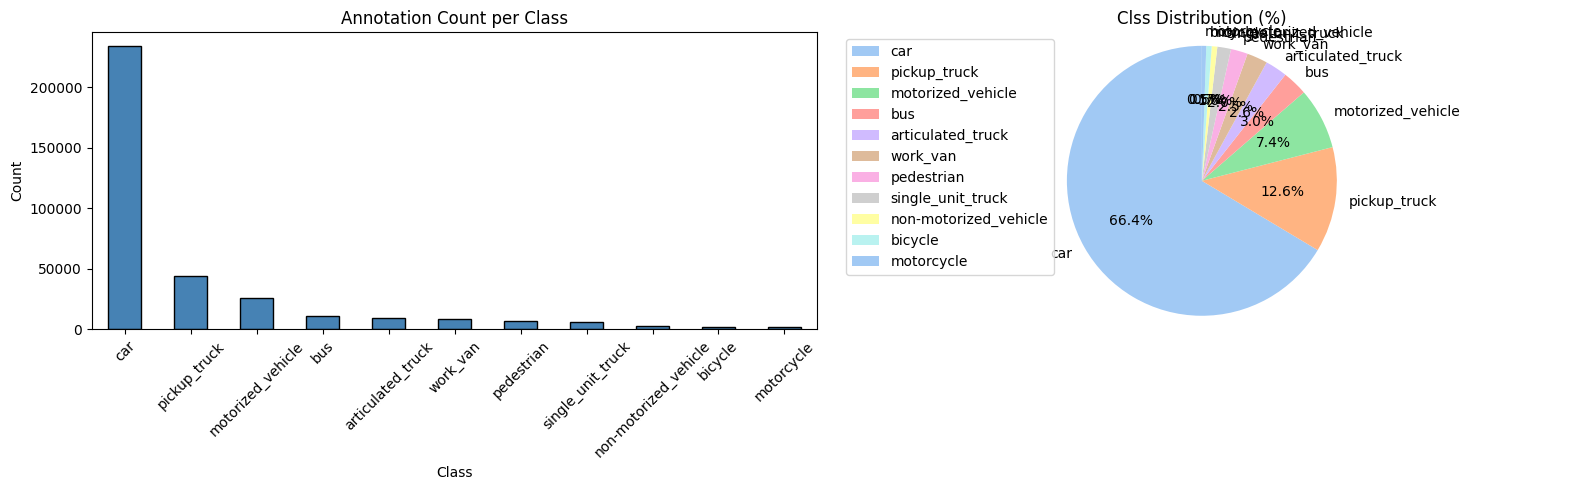

In [4]:
# Class Distribution

class_counts = df['label'].value_counts()
print("=== CLASS DISTRIBUTION ===")
print(class_counts)
print(f"\nNumber of unique classes: {class_counts.shape[0]}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
class_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Annotation Count per Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[1].axis('equal')
axes[1].set_title('Clss Distribution (%)')

plt.legend()
plt.tight_layout()
plt.show()

=== OBJECTS PER IMAGE ===
Min: 1
Max: 34
Mean: 3.20

Images with 1 object: 34,123
Images with 2-5 objects: 60,495
Images with 6+ objects: 15,382


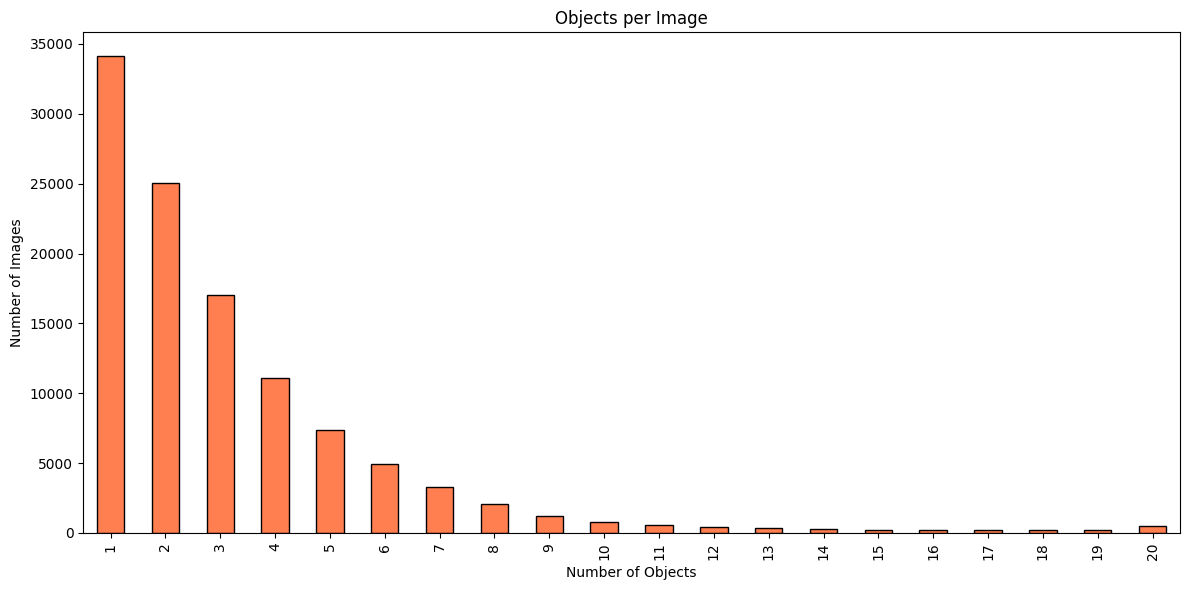

In [5]:
# --- OBJECTS PER IMAGE ------------------------
objs_per_image = df.groupby('image_id').size()

print("=== OBJECTS PER IMAGE ===")
print(f"Min: {objs_per_image.min():,}")
print(f"Max: {objs_per_image.max():,}")
print(f"Mean: {objs_per_image.mean():,.2f}")
print(f"\nImages with 1 object: {(objs_per_image == 1).sum():,}")
print(f"Images with 2-5 objects: {((objs_per_image >= 2) & (objs_per_image <= 5)).sum():,}")
print(f"Images with 6+ objects: {(objs_per_image >= 6).sum():,}")

plt.figure(figsize=(12, 6))
objs_per_image.clip(upper=20).value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Objects per Image')
plt.xlabel('Number of Objects')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

=== BOUNDING BOX ANALYSIS ===
xmin rangeL 0 to 706
ymin rangeL 0 to 471
xmax rangeL 6 to 719
ymax rangeL 5 to 479

Already normalized to [0,1]: False
→ Coordinates are in raw pixel values - normalization required before training.

Average box width: 87.3 px
Average box height: 55.2 px
Average box area: 8,586.2 sq px


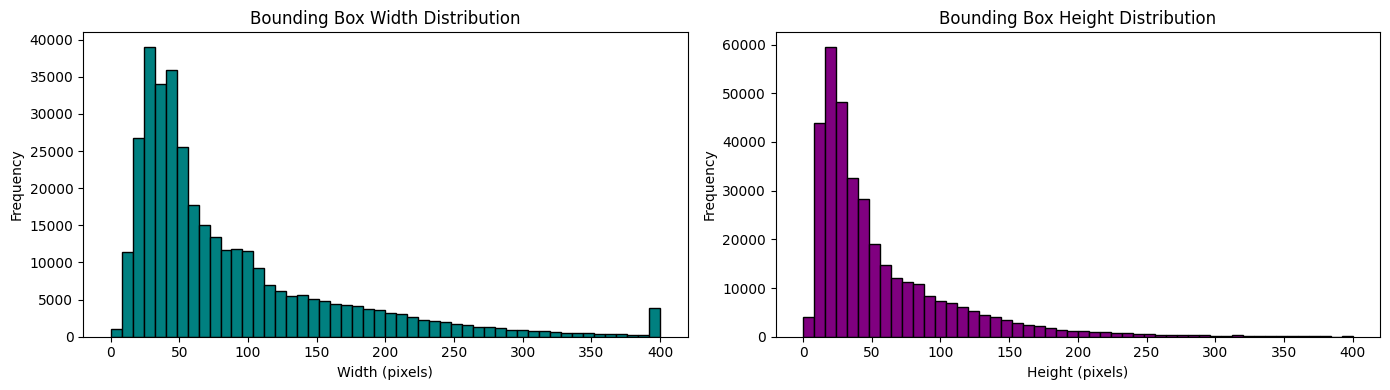

In [6]:
# ----- BOUNDING BOX ANALYSIS ----------------
print("=== BOUNDING BOX ANALYSIS ===")
print(f"xmin rangeL {df['xmin'].min()} to {df['xmin'].max()}")
print(f"ymin rangeL {df['ymin'].min()} to {df['ymin'].max()}")
print(f"xmax rangeL {df['xmax'].min()} to {df['xmax'].max()}")
print(f"ymax rangeL {df['ymax'].min()} to {df['ymax'].max()}")
#

already_normalized = (df[['xmin', 'ymin', 'xmax', 'ymax']] <= 1.0).all().all()
print(f"\nAlready normalized to [0,1]: {already_normalized}")
print("→ Coordinates are in raw pixel values - normalization required before training.")

# Box size distribution
df['box_width'] = df['xmax'] - df['xmin']
df['box_height'] = df['ymax'] - df['ymin']
df['box_area'] = df['box_width'] * df['box_height']

print(f"\nAverage box width: {df['box_width'].mean():,.1f} px")
print(f"Average box height: {df['box_height'].mean():,.1f} px")
print(f"Average box area: {df['box_area'].mean():,.1f} sq px")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['box_width'].clip(upper=400).plot(kind='hist', bins=50, ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Bounding Box Width Distribution')
axes[0].set_xlabel('Width (pixels)')

df['box_height'].clip(upper=400).plot(kind='hist', bins=50, ax=axes[1], color='purple', edgecolor='black')
axes[1].set_title('Bounding Box Height Distribution')
axes[1].set_xlabel('Height (pixels)')

plt.tight_layout()
plt.show()

In [7]:
# --- Image Size Verification ----
from PIL import Image
from pathlib import Path

# Sample 50 images to check if they're all the same size
sample_paths = list(Path(image_path).glob('*.jpg'))[:50]
sizes = {}
for p in sample_paths:
  with Image.open(p) as img:
    s = img.size  # (width, height)
    sizes[s] = sizes.get(s, 0) + 1

print("=== IMAGE SIZE DISTRIBUTION (sample of 50) ===")
for size, count in sorted(sizes.items()):
  print(f"  {size[0]} x {size[1]} px: {count} images")

if len(sizes) == 1:
  w, h = list(sizes.keys())[0]
  print(f"\nAll images are uniform: {w} x {h}")
  print("→ We can use a fixed normalization denominator (no per-image size lookup needed).")
else:
    print("\nImages have varying sizes → must read each image's dimensions individually.")

=== IMAGE SIZE DISTRIBUTION (sample of 50) ===
  342 x 228 px: 11 images
  720 x 480 px: 39 images

Images have varying sizes → must read each image's dimensions individually.


In [8]:
# Co-occurence of Classes Per Image
# Which classes appear together most often?
from itertools import combinations

co_occur = {}
for img_id, group in df.groupby('image_id'):
  labels_in_img = group['label'].unique().tolist()
  if len(labels_in_img) > 1:
    for pair in combinations(sorted(labels_in_img), 2):
      co_occur[pair] = co_occur.get(pair, 0) + 1

co_occur_df = pd.DataFrame(
    [(k[0], k[1], v) for k, v in co_occur.items()],
    columns=['class_a', 'class_b', 'count']
).sort_values('count', ascending=False)

print("=== TOP 10 CLASS CO-OCCURRENCE ===")
print(co_occur_df.head(10).to_string(index=False))

=== TOP 10 CLASS CO-OCCURRENCE ===
          class_a           class_b  count
              car      pickup_truck  22230
              car motorized_vehicle  16678
              car          work_van   6311
              bus               car   6112
motorized_vehicle      pickup_truck   5799
articulated_truck               car   5699
              car single_unit_truck   4279
              car        pedestrian   3279
articulated_truck motorized_vehicle   2050
     pickup_truck          work_van   1927


# **ARCHITECTURE DECISION:**
__Based on EDA findings:__
1. Multi-object per image (mean 3.2, max 34 objects) <br>
  → EfficientNetB0 dual-head output ONE bbox per image. → __ELIMINATED__
2. 11 Classes with heavy imbalance (car=66%) <br>
  → Need per-class mAP tracking, which __YOLO__ natively provides.
3. Small bouding boxes (traffic camera overhead perspective) <br>
  → __YOLOv8__ uses multi-scale detection heads (large/medium/small anchors).<br> Better suited for detecting small vehicles than a single GAP → Dense head.
4. 351,549 annotations across 110,000 images <br>
  → Large dataset benefits from YOLO's efficient anchor-based regression rather than a custom bbox head trained from scratch.

__CONCLUSION__: __YOLOv8 (Ultralytics)__ is the appropriate architecture.



In [9]:
!pip install -q ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 48.0/118.9 GB disk)


In [10]:
# Convert CSV Annotations -> YOLO.txt format
# Build class -> ID mapping
classes = sorted(df['label'].unique().tolist())
NUM_CLASSES = len(classes)
class_to_id = {i: c for i, c in enumerate(classes)}

print(f"Number of classes: {NUM_CLASSES}")
for idx, cls in class_to_id.items():
  print(f" {idx+1}: {cls}")


Number of classes: 11
 1: articulated_truck
 2: bicycle
 3: bus
 4: car
 5: motorcycle
 6: motorized_vehicle
 7: non-motorized_vehicle
 8: pedestrian
 9: pickup_truck
 10: single_unit_truck
 11: work_van


In [11]:
# DETECT IMAGE SIZE
from PIL import Image
from pathlib import Path

# Sample 50 images to check if they're all the same size
sample_imgs = list(Path(image_path).rglob('*.jpg'))[:20]
sizes = set()
for p in sample_imgs:
  with Image.open(p) as img:
    sizes.add(img.size) # (width, height)

print(f"Unique image sizes in sample: {sizes}")

if len(sizes) == 1:
  FIXED_W, FIXED_H = sizes.pop()
  UNIFORM_SIZE = True
  print(f"All images are the same size: {FIXED_W} x {FIXED_H}")
  print("→ We can use a fixed normalization denominator (no per-image size lookup needed).")
else:
  UNIFORM_SIZE = False
  print("Images have varying sizes → must read each image's dimensions individually.")
#

Unique image sizes in sample: {(342, 228), (720, 480)}
Images have varying sizes → must read each image's dimensions individually.


In [12]:
import os
import time
from tqdm import tqdm
from PIL import Image
from pathlib import Path

# -- Config ----------------
yolo_label_dir_local = '/content/yolo_labels'   # fast local writes
yolo_label_dir_drive = '/content/gdrive/MyDrive/MS-AI-Engineer-Capstone/Autonomous_Driving/Part 1/yolo_labels'
os.makedirs(yolo_label_dir_local, exist_ok=True)

# Correct the class_to_id mapping: it needs to be {class_name: id}
# The previous cell defined it as {id: class_name}
class_to_id_reversed = {c: i for i, c in class_to_id.items()}

# -- One-Time Drive Scan ----------------
print('Scanning image directory...')
scan_start = time.time()
image_files = list(Path(image_path).glob('*.jpg'))
existing_ids = {Path(p).stem for p in image_files}
print(f"Found {len(existing_ids):,} images in {time.time()-scan_start:.1f}s")

# --- Check if conversion is already done ---
print(f"Checking for existing labels in {yolo_label_dir_drive}...")
drive_label_files = list(Path(yolo_label_dir_drive).glob('*.txt'))
if len(drive_label_files) == len(existing_ids):
  print("All YOLO label files already exist in Google Drive. Skipping conversion.")
else:
  print(f"Found {len(drive_label_files):,} existing label files out of {len(existing_ids):,}. Proceeding with conversion.")

  # -- Conversion loop ------------------
  grouped = df.groupby('image_id')
  written = 0
  skipped = 0

  for image_id, group in tqdm(grouped, desc='Converting annotations'):
    # In-memory check - no Drive I/O
    if image_id not in existing_ids:
      skipped += 1
      continue

    # Get image dimensions for normalization based on UNIFORM_SIZE flag
    if UNIFORM_SIZE:
      img_w, img_h = FIXED_W, FIXED_H
    else:
      # Dynamically get image size if not uniform
      img_file_path = os.path.join(image_path, f'{image_id}.jpg')
      try:
        with Image.open(img_file_path) as img:
          img_w, img_h = img.size
      except FileNotFoundError:
        # This case should ideally be caught by existing_ids check, but good for robustness
        skipped += 1
        continue

    lines = []
    for _, row in group.iterrows():
      # Use the reversed mapping for class_id
      class_id = class_to_id_reversed[row['label']]

      # Correct column order and calculate YOLO format
      xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']

      cx = ((xmin + xmax) / 2) / img_w
      cy = ((ymin + ymax) / 2) / img_h
      bw = (xmax - xmin) / img_w
      bh = (ymax - ymin) / img_h

      # Clip values to be within [0,1]
      cx = max(0.0, min(1.0, cx))
      cy = max(0.0, min(1.0, cy))
      bw = max(0.0, min(1.0, bw))
      bh = max(0.0, min(1.0, bh))

      lines.append(f'{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}')

    # Write locally
    txt_path = os.path.join(yolo_label_dir_local, f'{image_id}.txt')
    with open(txt_path, 'w') as f:
      f.write('\n'.join(lines))

    written += 1

  print(f'\nWritten: {written:,} | Skipped: {skipped:,}')

  # -- Copy to Drive once ------------------------------
  print("\nCopying labels to Drive (one-time)...")
  import shutil
  shutil.copytree(yolo_label_dir_local, yolo_label_dir_drive, dirs_exist_ok=True)
  print("Labels saved to Drive")

Scanning image directory...
Found 5,626 images in 0.1s
Checking for existing labels in /content/gdrive/MyDrive/MS-AI-Engineer-Capstone/Autonomous_Driving/Part 1/yolo_labels...
All YOLO label files already exist in Google Drive. Skipping conversion.


In [13]:
# --- VERIFY CONVERTION
sample_id = df['image_id'].iloc[0]
sample_txt = os.path.join(yolo_label_dir_drive, f'{sample_id}.txt') # Changed to read from drive directory
sample_img = os.path.join(image_path, f'{sample_id}.jpg')

print(f'=== Original CSV rows for image {sample_id} ===')
print(df[df['image_id'] == sample_id][['label','xmin','ymin','xmax','ymax']].to_string())

print(f'\n=== Converted YOLO .txt for image {sample_id} ===')
with open(sample_txt) as f:
  print(f.read())

print(f'Format: class_id cx cy width height (all normalized to [0,1])')

=== Original CSV rows for image 00000000 ===
               label  xmin  ymin  xmax  ymax
0       pickup_truck   213    34   255    50
1                car   194    78   273   122
2                car   155    27   183    35
3  articulated_truck    43    25   109    55
4                car   106    32   124    45

=== Converted YOLO .txt for image 00000000 ===
8 0.684211 0.184211 0.122807 0.070175
3 0.682749 0.438596 0.230994 0.192982
3 0.494152 0.135965 0.081871 0.035088
0 0.222222 0.175439 0.192982 0.131579
3 0.336257 0.168860 0.052632 0.057018
Format: class_id cx cy width height (all normalized to [0,1])


# **BUILD FOLDER STRUCTURE & SPLIT DATASET (70/15/15)**

In [14]:
# Define the base directory for YOLO dataset
yolo_dataset_base_dir = '/content/gdrive/MyDrive/MS-AI-Engineer-Capstone/Autonomous_Driving/Part 1/yolo_dataset' # Changed to Google Drive path

# Create the main dataset directory
os.makedirs(yolo_dataset_base_dir, exist_ok=True)

# Define the splits
splits = ['train', 'test', 'val']

# Create directories for each split (images and labels)
for split in splits:
  os.makedirs(os.path.join(yolo_dataset_base_dir, split, 'images'), exist_ok=True)
  os.makedirs(os.path.join(yolo_dataset_base_dir, split, 'labels'), exist_ok=True)

print(f'YOLO dataset directory structure created at: {yolo_dataset_base_dir}')

YOLO dataset directory structure created at: /content/gdrive/MyDrive/MS-AI-Engineer-Capstone/Autonomous_Driving/Part 1/yolo_dataset


In [15]:
from sklearn.model_selection import train_test_split

# Get all unique image IDs from DataFrame
all_image_ids = df['image_id'].unique()

# Split 70% train, 15% val, 15% test
train_ids, test_val_ids = train_test_split(all_image_ids, test_size=0.3, random_state=42)
val_ids, test_ids = train_test_split(test_val_ids, test_size=0.5, random_state=42)

print(f"Total images: {len(all_image_ids)}")
print(f"Train images: {len(train_ids)}")
print(f"Validation images: {len(val_ids)}")
print(f"Test images: {len(test_ids)}")

Total images: 110000
Train images: 77000
Validation images: 16500
Test images: 16500


In [16]:
from sklearn.model_selection import train_test_split
import shutil
from pathlib import Path
import os
from tqdm import tqdm

# Get all unique image IDs from DataFrame
all_image_ids_from_df = df['image_id'].unique()

# --- Filter to only include image_ids for which files actually exist ---
# Get image IDs that actually exist in the image directory
# This was already found in cell fdRWy643nQF5 as 'existing_ids'
# For robustness, let's re-scan or ensure 'existing_ids' is available.
image_files_on_disk = list(Path(image_path).glob('*.jpg'))
existing_ids_on_disk = {Path(p).stem for p in image_files_on_disk}

# Get label IDs that actually exist in the drive label directory
label_files_on_disk = list(Path(yolo_label_dir_drive).glob('*.txt'))
existing_label_ids_on_disk = {Path(p).stem for p in label_files_on_disk}

# Find the intersection: image_ids that have both an image and a label file
common_existing_ids = list(existing_ids_on_disk.intersection(existing_label_ids_on_disk))

print(f"Total unique image IDs in DataFrame: {len(all_image_ids_from_df)}")
print(f"Total image files found on disk: {len(existing_ids_on_disk)}")
print(f"Total label files found on disk: {len(existing_label_ids_on_disk)}")
print(f"Total common image_ids with both image and label files: {len(common_existing_ids)}")

# Now, split these common_existing_ids
# Split 70% train, 15% val, 15% test
train_ids, test_val_ids = train_test_split(common_existing_ids, test_size=0.3, random_state=42)
val_ids, test_ids = train_test_split(test_val_ids, test_size=0.5, random_state=42)

print(f"\nTrain images (based on existing files): {len(train_ids)}")
print(f"Validation images (based on existing files): {len(val_ids)}")
print(f"Test images (based on existing files): {len(test_ids)}")

# Define the source directories
source_image_dir = image_path
source_label_dir = yolo_label_dir_drive # Changed to read from Google Drive

# Function to copy file
def copy_files(image_ids, split_name):
  for img_id in tqdm(image_ids, desc=f'Copying {split_name} files'):
    # Copy Image
    src_img_path = os.path.join(source_image_dir, f'{img_id}.jpg')
    dst_img_path = os.path.join(yolo_dataset_base_dir, split_name, 'images', f'{img_id}.jpg')
    # Only copy if the image file exists AND the destination does not exist
    if os.path.exists(src_img_path) and not os.path.exists(dst_img_path):
      shutil.copy(src_img_path, dst_img_path)

    # Copy Label
    src_label_path = os.path.join(source_label_dir, f'{img_id}.txt')
    dst_label_path = os.path.join(yolo_dataset_base_dir, split_name, 'labels', f'{img_id}.txt')
    # Only copy if the label file exists (which it should, given 'common_existing_ids') AND the destination does not exist
    if os.path.exists(src_label_path) and not os.path.exists(dst_label_path):
      shutil.copy(src_label_path, dst_label_path)
    elif not os.path.exists(src_label_path):
      print(f"[DIAGNOSTIC] Label source file not found: {src_label_path}")

# --- Check if splitting and copying is already done ---
already_copied = True
for split_name, ids_list in [('train', train_ids), ('val', val_ids), ('test', test_ids)]:
  expected_count_for_split = len(ids_list) # This is the count of *actually existing* files for this split

  actual_images_in_dst = len(list(Path(os.path.join(yolo_dataset_base_dir, split_name, 'images')).glob('*.jpg')))
  actual_labels_in_dst = len(list(Path(os.path.join(yolo_dataset_base_dir, split_name, 'labels')).glob('*.txt')))

  if actual_images_in_dst != expected_count_for_split or actual_labels_in_dst != expected_count_for_split:
    print(f"Mismatch found in {split_name} split. Images: {actual_images_in_dst}/{expected_count_for_split}, Labels: {actual_labels_in_dst}/{expected_count_for_split}")
    already_copied = False
    break

if already_copied:
  print("Dataset splitting and copying already complete. Skipping.")
else:
  print("Proceeding with dataset splitting and copying.")
  # Copy files for each split
  copy_files(train_ids, 'train')
  copy_files(val_ids, 'val')
  copy_files(test_ids, 'test')

  print('\nDataset splitting and copying complete!')

# Removed redundant print statements for file counts as the 'Mismatch found' message already covers this.
# These print statements below were causing confusion and were also showing a typo in 'os.op.join' which is now fixed.

Total unique image IDs in DataFrame: 110000
Total image files found on disk: 5626
Total label files found on disk: 5626
Total common image_ids with both image and label files: 5626

Train images (based on existing files): 3938
Validation images (based on existing files): 844
Test images (based on existing files): 844
Dataset splitting and copying already complete. Skipping.


# **Create `data.yaml`**
This is the config file YOLOv8 reads during training. It tells the model:
- Where to find train/val/test images
- How many classes exist
- What each class ID maps to

In [17]:
import yaml

YAML_PATH = os.path.join(yolo_dataset_base_dir, 'data.yaml')

yaml_content = {
    'path': yolo_dataset_base_dir,  # root dataset directory now points to Drive
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': NUM_CLASSES,      # number of classes
    'names': classes        # list of class names (index = class_id)
}

with open(YAML_PATH, 'w') as f:
  yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print('data.yaml created')
print('-'*40)
with open(YAML_PATH) as f:
  print(f.read())

data.yaml created
----------------------------------------
path: /content/gdrive/MyDrive/MS-AI-Engineer-Capstone/Autonomous_Driving/Part 1/yolo_dataset
train: train/images
val: val/images
test: test/images
nc: 11
names:
- articulated_truck
- bicycle
- bus
- car
- motorcycle
- motorized_vehicle
- non-motorized_vehicle
- pedestrian
- pickup_truck
- single_unit_truck
- work_van



# **Visualize Sample Image with Ground Truth Boxes**

/tmp/ipykernel_6550/866813620.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COLORS = plt.cm.get_cmap('tab20', NUM_CLASSES)


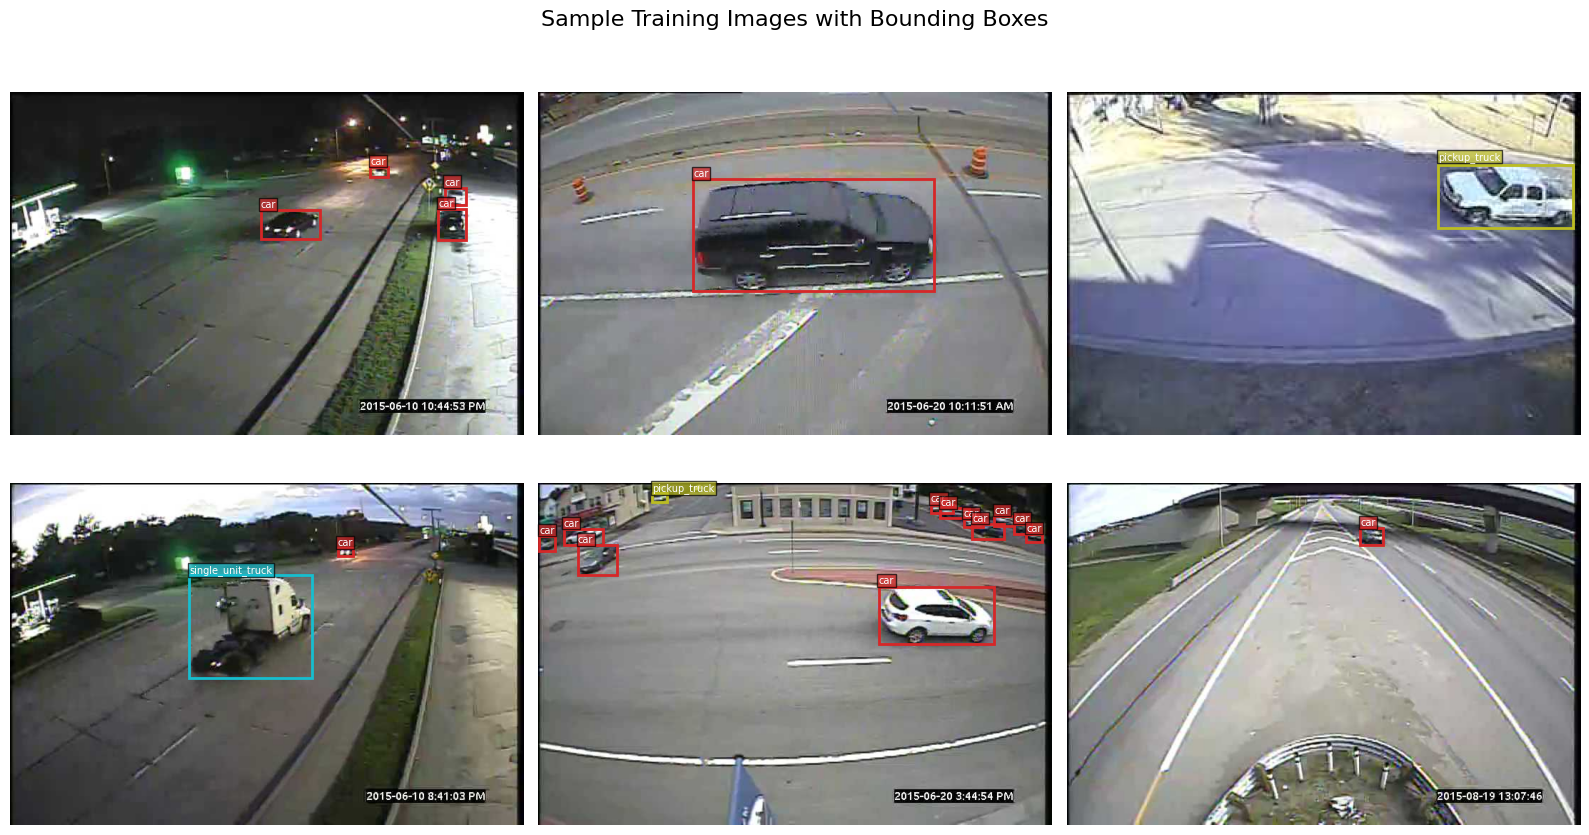

In [18]:
import cv2
import matplotlib.patches as patches
import random
import os
from pathlib import Path
import matplotlib.pyplot as plt

random.seed(42)

id_to_class = class_to_id # Corrected: class_to_id already maps int ID to class name
COLORS = plt.cm.get_cmap('tab20', NUM_CLASSES)

def show_yolo_sample(img_path, txt_path, ax):
  """Draws YOLO-format bounding boxes on an image"""
  img = cv2.imread(str(img_path)) # Convert Path object to string for cv2.imread
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  h, w = img.shape[:2]
  ax.imshow(img)

  if os.path.exists(txt_path):
    with open(txt_path) as f:
      for line in f:
        parts = line.strip().split()
        if len(parts) != 5:
          continue
        cls_id, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:])

        # Denormalize back to pixel coords for display
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)

        color = COLORS(cls_id)[:3]
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1-4, id_to_class[cls_id], # Use id_to_class for mapping class_id to name
                color='white', fontsize=7,
                bbox=dict(facecolor=color, alpha=0.7, pad=1))
  ax.axis('off')

# Pick 6 random training images
sample_imgs = random.sample(list(Path(os.path.join(yolo_dataset_base_dir, 'train', 'images')).glob('*.jpg')), 6)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, img_path in zip(axes.flatten(), sample_imgs):
  txt_path = os.path.join(yolo_dataset_base_dir, 'train', 'labels', img_path.stem + '.txt') # Use img_path.stem
  show_yolo_sample(img_path, txt_path, ax)

plt.suptitle('Sample Training Images with Bounding Boxes', fontsize=16)
plt.tight_layout()
plt.show()

#**Train YOLOv8**

In [19]:
from ultralytics import YOLO

# ---- Hyperparameters -------------------
IMG_SIZE = 640          # YOLOv8 standard input size
BATCH_SIZE = 16         # reduce to 8 if Colab runs out of GPU memory
EPOCHS = 50             # increase to 100 for better accuracy
MODEL_SIZE  = 'n'       # 'n'=nano (fastest), 's'=small, 'm'=medium
SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Load pre-trained YOLOv8 nano model
model = YOLO(f'yolov8{MODEL_SIZE}.pt')

# Train
results = model.train(
    data=YAML_PATH,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    seed=SEED,
    project=yolo_dataset_base_dir,
    patience=15,            # early stopping: stop if no improvement for 15 epochs
    save=True,              # save best and last weights
    plots=True,             # save training plots (loss curves, confusion matrix)
    verbose=True,
    name='yolov8_vehicle',
    exist_ok=True
)

print('\nTraining complete!')
print(f'Best weights saved at: {yolo_dataset_base_dir}/yolov8_vehicle/weights/best.pt')

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gdrive/MyDrive/MS-AI-Engineer-Capstone/Autonomous_Driving/Part 1/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_vehicle, nbs=64, nms=False, o

#**PLOT TRAINING CURVES**

In [ ]:
results_csv = os.path.join(yolo_dataset_base_dir, 'yolov8_vehicle', 'results.csv')
res_df = pd.read_csv(results_csv)
res_df.columns = res_df.columns.str.strip()   # strip whitespace from col names

print('Available columns:', res_df.columns.tolist())
res_df.head()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = [
    ('train/box_loss', 'val/box_loss', 'Box Loss (Localization)'),
    ('train/cls_loss', 'val/cls_loss', 'Classification Loss'),
    ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss'),
    ('metrics/mAP50(B)', None,         'mAP@50'  ),
    ('metrics/mAP50-95(B)', None,      'mAP@50-95'),
    ('metrics/precision(B)', None,     'Precision'),
]

for ax, (train_col, val_col, title) in zip(axes.flatten(), metrics_to_plot):
  if train_col in res_df.columns:
    ax.plot(res_df[train_col], label='Train')
  if val_col and val_col in res_df.columns:
    ax.plot(res_df[val_col], label='Val', linestyle='--')
  ax.set_title(title)
  ax.set_xlabel('Epoch')
  ax.legend()
  ax.grid(alpha=0.3)

plt.suptitle('YOLOv8 Training History', fontsize=14)
plt.tight_layout()
plt.show()

#**EVALUATE ON VALIDATION & TEST SET**
Key metrics for object detection:
- **mAP@50** - mean Average Precision at IoU threshold 0.50 (primary metric)
- **mAP@50-95** - averaged across IoU thresholds 0.50 to 0.95 (stricter)
- **Precision** - of all predictied boxes, how many are correct
- **Recall** - of all actual objects, how many were found

In [ ]:
# Load best weights
BEST_WEIGHTS = os.path.join(yolo_dataset_base_dir, 'yolov8_vehicle', 'weights', 'best.pt')
best_model = YOLO(BEST_WEIGHTS)

# ---- VALIDATION SET EVALUATION -----------------
print('=== Validation Set Metrics ===')
val_metrics = best_model.val(
    data=YAML_PATH,
    split='val',
    imgsz=IMG_SIZE,
    verbose=True
)

print(f'\nmAP@50    : {val_metrics.box.map50:.4f}')
print(f'mAP@50-95: {val_metrics.box.map:.4f}')
print(f'Precision: {val_metrics.box.mp:.4f}')
print(f'Recall: {val_metrics.box.mr:.4f}')

In [ ]:
# ---- TEST SET EVALUATION ------------------
print('=== Test Set Metrics ===')
test_metrics = best_model.val(
    data=YAML_PATH,
    split='test',
    imgsz=IMG_SIZE,
    verbose=True
)

print(f'\nmAP@50    : {test_metrics.box.map50:.4f}')
print(f'mAP@50-95: {test_metrics.box.map:.4f}')
print(f'Precision: {test_metrics.box.mp:.4f}')
print(f'Recall: {test_metrics.box.mr:.4f}')

In [ ]:
# ---- PER-CLASS  mAP TABLE ---------------
# YOLOv8 saves a per-class breakdown in results
val_results_dir = os.path.join(yolo_dataset_base_dir, 'yolov8_vehicle')

# Display the confusion matrix if it was saved
conf_matrix_path = os.path.join(val_results_dir, 'confusion_matrix.png')
if os.path.exists(conf_matrix_path):
  img = plt.imread(conf_matrix_path)
  plt.figure(figsize=(12, 10))
  plt.imshow(img)
  plt.axis('off')
  plt.title('Confusion Matrix (Validation Set)')
  plt.show()
else:
  print(f'Confusion matrix not found at: {conf_matrix_path}')

#**RUN INFERENCE ON SAMPLE IMAGES**

In [ ]:
# --- INFERENCE ON TEST IMAGES -------------
TEST_IMG = os.path.join(yolo_dataset_base_dir, 'test', 'images')
sample_test_imgs = random.sample(list(Path(TEST_IMG).glob('*.jpg')), 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, img_path in zip(axes.flatten(), sample_test_imgs):
  # Run inference
  result = best_model.predict(
      source=str(img_path),
      imgsz=IMG_SIZE,
      conf=0.25,    # confidence threshold: only show boxes > 25% confident
      iou=0.45,     # NMS IoU threshold
      verbose=False
  )[0]

  # YOLOv8 result.plot() returns a BGR numpy array with boxes drawn
  annotated = result.plot()
  annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

  ax.imshow(annotated)
  n_detections = len(result.boxes)
  ax.set_title(f'{img_path.stem} - {n_detections} detection(s)', fontsize=9)
  ax.axis('off')

plt.suptitle('YOLOv8 Inference on Test Images', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# ---- DETAILED INSPECTION: ON IMAGE -----------------------
# Pick one image and print all detected objects with their confidence scores

single_img = str(sample_test_imgs[0])
result = best_model.predict(
    source=single_img,
    imgsz=IMG_SIZE,
    conf=0.25,
    verbose=False
)[0]

print(f'Image: {Path(single_img).name}')
print(f'Detections: {len(result.boxes)}\n')
print(f'{"Class":<25} {"Confidence":>12} {"BBox (xmin,ymin,xmax,ymax)"}')
print('-'*70)

for box in result.boxes:
  cls_name = classes[int(box.cls)]
  conf_score = float(box.conf)
  xyxy = box.xyxy[0].tolist() # pixel coords
  print(f'{cls_name:<25} {conf_score:>12.4f}. {[round(v,1) for v in xyxy]}')

#**SAVE BEST MODEL TO GOOGLE DRIVE**

In [ ]:
drive_save_dir = '/content/gdrive/MyDrive/MS-AI-Engineer-Capstone/Autonomous_Driving/Part 1/model_output'
os.makedirs(drive_save_dir, exist_ok=True)

# Copy best weights
shutil.copy(BEST_WEIGHTS, os.path.join(drive_save_dir, 'best.pt'))

# Copy training results CSV and plots
shutil.copy(
    os.path.join(yolo_dataset_base_dir, 'yolov8_vehicle', 'results.csv'),
    os.path.join(drive_save_dir, 'results.csv')
)

print(f'Model and results saved to Drive: {drive_save_dir}')

In [ ]:
# --- INFERENCE UTILITY FUNCTION (reusable by API) ----
import base64, cv2, io
from PIL import Image
import numpy as np

def run_inference(image_input, conf=0.25, iou=0.45):
    """
    Args:
        image_input: file path (str) OR PIL Image OR numpy array
        conf: confidence threshold
        iou: NMS IoU threshold
    Returns:
        dict with annotated_image_b64, detection list, summary metrics
    """
    result = best_model.predict(
        source=image_input,
        imgsz=640,
        conf=conf,
        iou=iou,
        verbose=False
    )[0]

    # Annotated image as base64 (what the frontend will display)
    annotated_bgr = result.plot()   # BGR numpy array with boxes drawn
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(annotated_rgb)
    buf = io.BytesIO()
    pil_img.save(buf, format='JPEG', quality=90)
    img_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')

    # Per-detection breakdown
    detections = []
    for box in result.boxes:
        detections.append({
            'class': classes[int(box.cls)],
            'confidence': round(float(box.conf), 4),
            'bbox': [round(v, 1) for v in box.xyxy[0].tolist()]     # xmin, ymin, xmax, ymax
        })

    # Summary
    summary = {
        'total_detections': len(detections),
        'class_counts': {},
        'avg_confidence': round(
            sum(d['confidence'] for d in detections) / len(detections), 3
        ) if detections else 0
    }
    for d in detections:
        summary['class_counts'][d['class']] = summary['class_counts'].get(d['class'],0) + 1

    return {
        'annotated_image_b64': img_b64,
        'detections': detections,
        'summary': summary
    }

In [ ]:
# --- TEST FUNCTION ----
test_img_path = str(sample_test_imgs[0])
output = run_inference(test_img_path, conf=0.25, iou=0.45)
print(f"Detection: {output['summary']['total_detections']}")
print(f"Classes: {output['summary']['class_counts']}")
print(f"Avg confidence: {output['summary']['avg_confidence']}")

In [ ]:
# In Colab - copy best.pt to a predictable location then download it
import shutil
from google.colab import files

model_export_path = '/content/best.pt'
shutil.copy(BEST_WEIGHTS, model_export_path)
files.download(model_export_path)
print("Download best.pt - keep this file, it's your trained model weights")